# Stage 1 Feature Analysis & Selection

This notebook covers the feature-engineering and feature-selection story for Chapter 5:
where the 16 candidate features come from, how the synthetic dataset that trains the
classifier is put together, how each feature actually separates Valid from Invalid
curves, and how the final production feature set was chosen.

Structure:
1. Load the data
2. The synthetic curve generator (composition, example curves)
3. The 16 candidate features, in four groups
4. How each feature separates Valid from Invalid (distributions, tests, effect sizes)
5. Correlation among the 16
6. Cross-validated feature ranking
7. Final comparison: Full set vs Top 8 vs Top 10 vs a greedy-selected subset, plus the
   production "Average" ensemble
8. Save results for the thesis
9. Production-configuration demo (Stage 1 + Stage 2 together)

This version was re-synced against the `growthqa` codebase at commit `f4cada8`
(2026-07-11). See the note at the end of Section 7 for what changed and why.


In [1]:
import importlib
import sys
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score


def ensure_local_growthqa():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, cwd.parent, cwd.parent.parent]:
        src_candidate = candidate / "src"
        module_path = src_candidate / "growthqa" / "classifier" / "train_from_meta.py"
        if module_path.exists():
            if str(src_candidate) not in sys.path:
                sys.path.insert(0, str(src_candidate))
            return src_candidate
    return None

SRC_ROOT = ensure_local_growthqa()
if SRC_ROOT is None:
    raise RuntimeError("Could not locate the local src directory for growthqa")

sys.modules.pop("growthqa.classifier.train_from_meta", None)
importlib.invalidate_caches()
train_from_meta = importlib.import_module("growthqa.classifier.train_from_meta")
train_from_meta = importlib.reload(train_from_meta)

from growthqa.classifier.train_from_meta import (
    build_model_matrix, build_models, STAGE1_FEATURE_GROUPS, STAGE1_CANDIDATE_POOL, train_from_meta_csv
)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Using src root:", SRC_ROOT)
print("Loaded module:", train_from_meta.__file__)


Using src root: C:\Users\prern\Downloads\ThesisFinal\curveql\src
Loaded module: C:\Users\prern\Downloads\ThesisFinal\curveql\src\growthqa\classifier\train_from_meta.py


In [2]:
# ---- Configuration ----
N_CV_FOLDS = 7
RF_N_ESTIMATORS = 200          # used for the final permutation-importance ranking
RF_PROXY_N_ESTIMATORS = 80     # lighter model reused inside the greedy search loop
GREEDY_MAX_STEPS = 10
GREEDY_PLATEAU_GAIN = 0.003


## 1. The synthetic curve generator

Most of the training data (2700 of the 2976 rows here) comes from
`growthqa.synthetic.timeseries_curve_data`, not from real lab measurements. It builds a
fixed, reproducible composition of curves rather than randomly sampling an unspecified
mixture, so the exact makeup of the dataset can be reported plainly.

Four **valid** subtypes (plain, fast, late, decline) and seven **invalid** subtypes
(obvious, diauxic, subtle, nearreal, decline_only, noise, nogrowth) are generated in
fixed counts. A fraction of the valid curves also get missing readings or negative
outliers injected, so the valid class isn't uniformly clean -- it includes curves a
classifier genuinely has to work to recognize as valid.


In [3]:
wide_synth = pd.read_csv("../data/pipeline_data/timeseries_wide_SD1.csv")

composition = (
    wide_synth.groupby(["Is_Valid", "Curve Subtype"]).size()
    .rename("count").reset_index()
    .sort_values(["Is_Valid", "count"], ascending=[False, False])
)
composition["Is_Valid"] = composition["Is_Valid"].map({True: "Valid", False: "Invalid"})
composition


,Is_Valid,Curve Subtype,count
10,Valid,plain,203
7,Valid,decline,100
8,Valid,fast,100
9,Valid,late,100
5,Invalid,obvious,80
1,Invalid,diauxic,60
6,Invalid,subtle,60
0,Invalid,decline_only,55
2,Invalid,nearreal,55
4,Invalid,noise,45


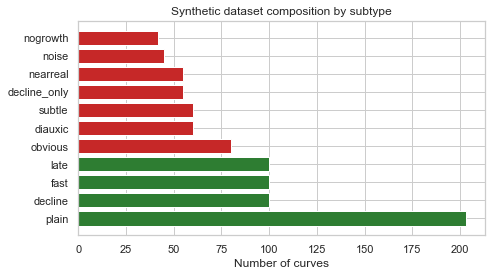

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
order = composition.sort_values("count", ascending=False)
colors = ["#2e7d32" if v == "Valid" else "#c62828" for v in order["Is_Valid"]]
ax.barh(order["Curve Subtype"], order["count"], color=colors)
ax.set_xlabel("Number of curves")
ax.set_title("Synthetic dataset composition by subtype")
plt.tight_layout()
plt.show()


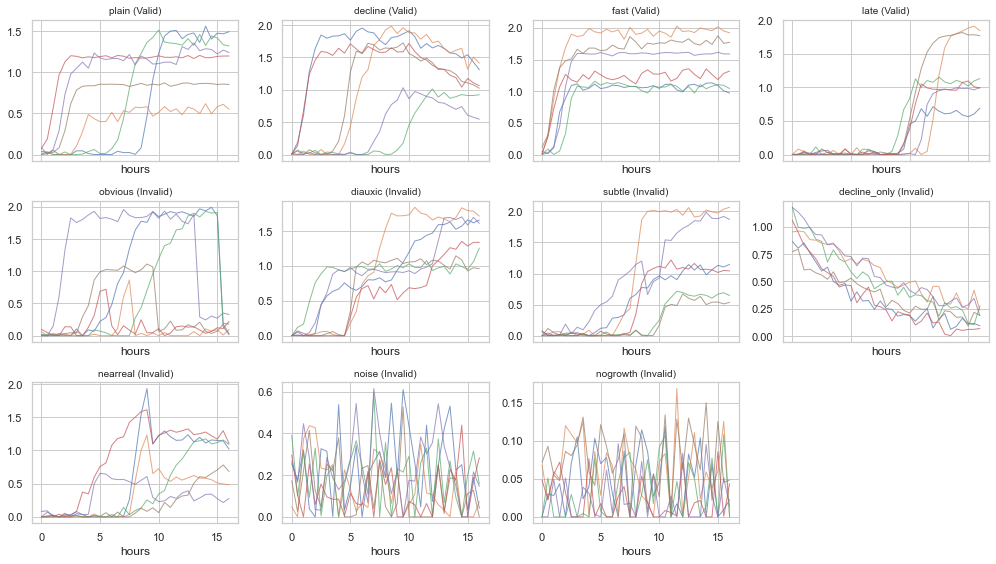

In [5]:
from growthqa.preprocess.timegrid import get_sorted_time_columns, parse_time_from_header

time_cols = get_sorted_time_columns(wide_synth)
t_vals = [parse_time_from_header(c) for c in time_cols]

subtypes = composition["Curve Subtype"].tolist()
fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=True)
for ax, subtype in zip(axes.flat, subtypes):
    sub = wide_synth[wide_synth["Curve Subtype"] == subtype]
    sample = sub.sample(min(6, len(sub)), random_state=42)
    for _, row in sample.iterrows():
        ax.plot(t_vals, row[time_cols].values, alpha=0.7, linewidth=1)
    is_valid = sub["Is_Valid"].iloc[0]
    ax.set_title(f"{subtype} ({'Valid' if is_valid else 'Invalid'})", fontsize=10)
    ax.set_xlabel("hours")
for ax in axes.flat[len(subtypes):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. Load the data from synthetic and lab

`training_meta.csv` is produced by `build-train-meta` from the synthetic wide file and
the lab wide file together (see `build_meta_dataset.run_merge_preprocess_meta`). It
already carries every candidate feature computed the same way for training and
inference.


In [6]:
RAW_CSV = Path("../data/train_data/raw_merged.csv")
raw = pd.read_csv(RAW_CSV)

print("Rows:", raw.shape[0], "| base curves:", raw["Test Id"].nunique())
print("Label balance:", raw["Is_Valid"].value_counts().rename({1: "Valid", 0: "Invalid"}).to_dict())
print("Source split:", raw["FileName"].value_counts().to_dict())


Rows: 992 | base curves: 992
Label balance: {'Valid': 595, 'Invalid': 397}
Source split: {'SD1': 900, 'growth.xlsx': 92}


In [7]:
FINAL_CSV = Path("../data/train_data/final_merged.csv")
final = pd.read_csv(FINAL_CSV)

print("Rows:", final.shape[0], "| base curves:", final["base_curve_id"].nunique())
print("Label balance:", final["Is_Valid"].value_counts().rename({1: "Valid", 0: "Invalid"}).to_dict())
print("Source split:", final["FileName"].value_counts().to_dict())

Rows: 3572 | base curves: 992
Label balance: {'Valid': 2153, 'Invalid': 1419}
Source split: {'SD1': 3236, 'growth.xlsx': 336}


In [8]:
META_CSV = Path("../data/train_data/training_meta.csv")
meta = pd.read_csv(META_CSV)

print("Rows:", meta.shape[0], "| base curves:", meta["base_curve_id"].nunique())
print("Label balance:", meta["Is_Valid"].value_counts().rename({1: "Valid", 0: "Invalid"}).to_dict())
print("Source split:", meta["source_type"].value_counts().to_dict())


Rows: 3572 | base curves: 992
Label balance: {'Valid': 2153, 'Invalid': 1419}
Source split: {'synthetic': 3236, 'lab': 336}


In [9]:
raw.head(2)

,FileName,Test Id,Model Name,Is_Valid,T0.0 (h),T0.5 (h),T1.0 (h),T1.5 (h),T2.0 (h),T2.5 (h),...,T11.5 (h),T12.0 (h),T12.5 (h),T13.0 (h),T13.5 (h),T14.0 (h),T14.5 (h),T15.0 (h),T15.5 (h),T16.0 (h)
0,SD1,SD1_1,Flat,False,0.201682,0.145564,0.095291,0.326666,0.000000,0.116325,...,0.055798,0.164285,0.256628,0.207727,0.000000,0.333353,0.079466,0.039786,0.335845,0.028299
1,SD1,SD1_10,Logistic,False,0.000000,0.000000,0.022792,0.098350,0.060559,0.077406,...,0.014210,0.084266,0.010730,0.092704,0.053486,0.000000,0.000000,0.091315,0.027440,0.000000


In [10]:
final.head(2)

,FileName,Test Id,Model Name,base_curve_id,aug_id,Is_Valid,tmax_original,train_horizon,is_censored,too_sparse,...,T11.5 (h),T12.0 (h),T12.5 (h),T13.0 (h),T13.5 (h),T14.0 (h),T14.5 (h),T15.0 (h),T15.5 (h),T16.0 (h)
0,SD1,SD1_1,Flat,SD1_1_A,SD1_1_A_H10,False,16.0,10.0,1,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SD1,SD1_1,Flat,SD1_1_A,SD1_1_A_H16,False,16.0,16.0,0,False,...,0.260922,0.575419,0.872522,0.51051,0.547994,0.588204,0.480156,0.45502,0.386838,0.435404


In [11]:
meta.head(2)

,FileName,Test Id,Model Name,Is_Valid,source_type,is_synthetic,base_curve_id,aug_id,tmax_original,gap_augmented,...,largest_drop_frac,roughness,noise_residual_std,noise_residual_std_is_fallback,lag_time_est,plateau_OD,growth_phase_duration,symmetry_factor,num_slope_sign_changes,multi_phase_flag
0,SD1,SD1_1,Flat,0,synthetic,1,SD1_1_A,SD1_1_A_H10,16.0,0,...,0.579572,0.269333,0.208346,0,0.5,0.386899,NaN,0.600,9,0.0
1,SD1,SD1_1,Flat,0,synthetic,1,SD1_1_A,SD1_1_A_H16,16.0,0,...,0.525333,0.243329,0.188739,0,0.5,0.455020,NaN,0.375,14,0.0


## 3. The 16 candidate features, in four groups

Rather than throwing every computable curve statistic at the classifier, the candidate
pool is organized around four questions, each covering a failure mode the others don't:

- **Observation quality** -- can we even trust the shape we're about to measure?
- **Level** -- where did it start and end?
- **Growth dynamics** -- how did it get from start to end?
- **Shape integrity** -- does the trajectory look like real growth, or an artifact?

This is imported directly from `train_from_meta.STAGE1_FEATURE_GROUPS`, so the notebook
and the production code can never drift apart on what the candidate pool actually is.


In [12]:
for group, feats in STAGE1_FEATURE_GROUPS.items():
    print(f"{group} ({len(feats)}): {feats}")
print()
print("Total candidate features:", len(STAGE1_CANDIDATE_POOL))


observation_quality (4): ['observed_tmax', 'n_points_observed', 'max_gap_hours', 'missing_frac_on_grid']
level (2): ['initial_OD', 'final_OD']
growth_dynamics (5): ['net_change_per_hour', 'max_slope', 'auc_per_hour', 'lag_time_est', 'growth_phase_duration']
shape_integrity (5): ['monotonicity_fraction', 'largest_drop_frac', 'multi_phase_flag', 'roughness', 'noise_residual_std']

Total candidate features: 16


## 4. How each feature separates Valid from Invalid

For each feature: a distribution split by label, a Mann-Whitney U test (curves aren't
normally distributed, so a rank-based test is more appropriate than a t-test), and the
AUC you'd get from using that single feature alone as a classifier -- an intuitive
separability score where 0.5 is random and 1.0 is perfect separation.


In [13]:
X_all, y_all, groups_all, feature_cols_all, eval_df_all = build_model_matrix(meta, label_col="Is_Valid")
X16 = X_all[STAGE1_CANDIDATE_POOL].copy()

# Mann-Whitney U alone only gives a p-value. With n=3572, almost any real
# difference clears p < 0.05, so p-value ranking mostly just reflects sample
# size, not how much the feature actually separates the classes. The
# rank-biserial correlation (derived from the same U statistic) is reported
# alongside it as an effect size on a fixed -1..1 scale, and used for sorting
# instead of the p-value.
rows = []
for feat in STAGE1_CANDIDATE_POOL:
    valid_vals = X16.loc[y_all == 1, feat].dropna()
    invalid_vals = X16.loc[y_all == 0, feat].dropna()
    n1, n2 = len(valid_vals), len(invalid_vals)
    u_stat, p_val = stats.mannwhitneyu(valid_vals, invalid_vals, alternative="two-sided")
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
    # AUC of the raw feature value as a single-feature classifier
    filled = X16[feat].fillna(X16[feat].median())
    auc_single = roc_auc_score(y_all, filled)
    auc_single = max(auc_single, 1 - auc_single)  # direction-agnostic separability
    rows.append({
        "feature": feat, "n_valid": n1, "n_invalid": n2,
        "mannwhitney_p": p_val, "rank_biserial_r": rank_biserial,
        "single_feature_auc": auc_single,
    })

separability = pd.DataFrame(rows).sort_values("single_feature_auc", ascending=False).reset_index(drop=True)
separability


,feature,n_valid,n_invalid,mannwhitney_p,rank_biserial_r,single_feature_auc
0,largest_drop_frac,2153,1419,3.462465e-259,0.678999,0.839500
1,final_OD,2153,1419,5.086734e-161,-0.528408,0.764204
2,net_change_per_hour,2153,1419,3.153857e-139,-0.495929,0.747965
3,monotonicity_fraction,2153,1419,1.790105e-70,-0.350212,0.675106
4,initial_OD,2153,1419,2.519108e-69,0.342393,0.671196
5,roughness,2153,1419,1.705818e-59,0.321172,0.660586
6,multi_phase_flag,2152,1419,6.110994e-66,0.186013,0.593016
7,auc_per_hour,2153,1419,1.384729e-18,-0.173724,0.586862
8,noise_residual_std,2153,1419,4.652591e-18,0.171018,0.585509
9,growth_phase_duration,1998,912,5.491938e-17,0.192317,0.571994


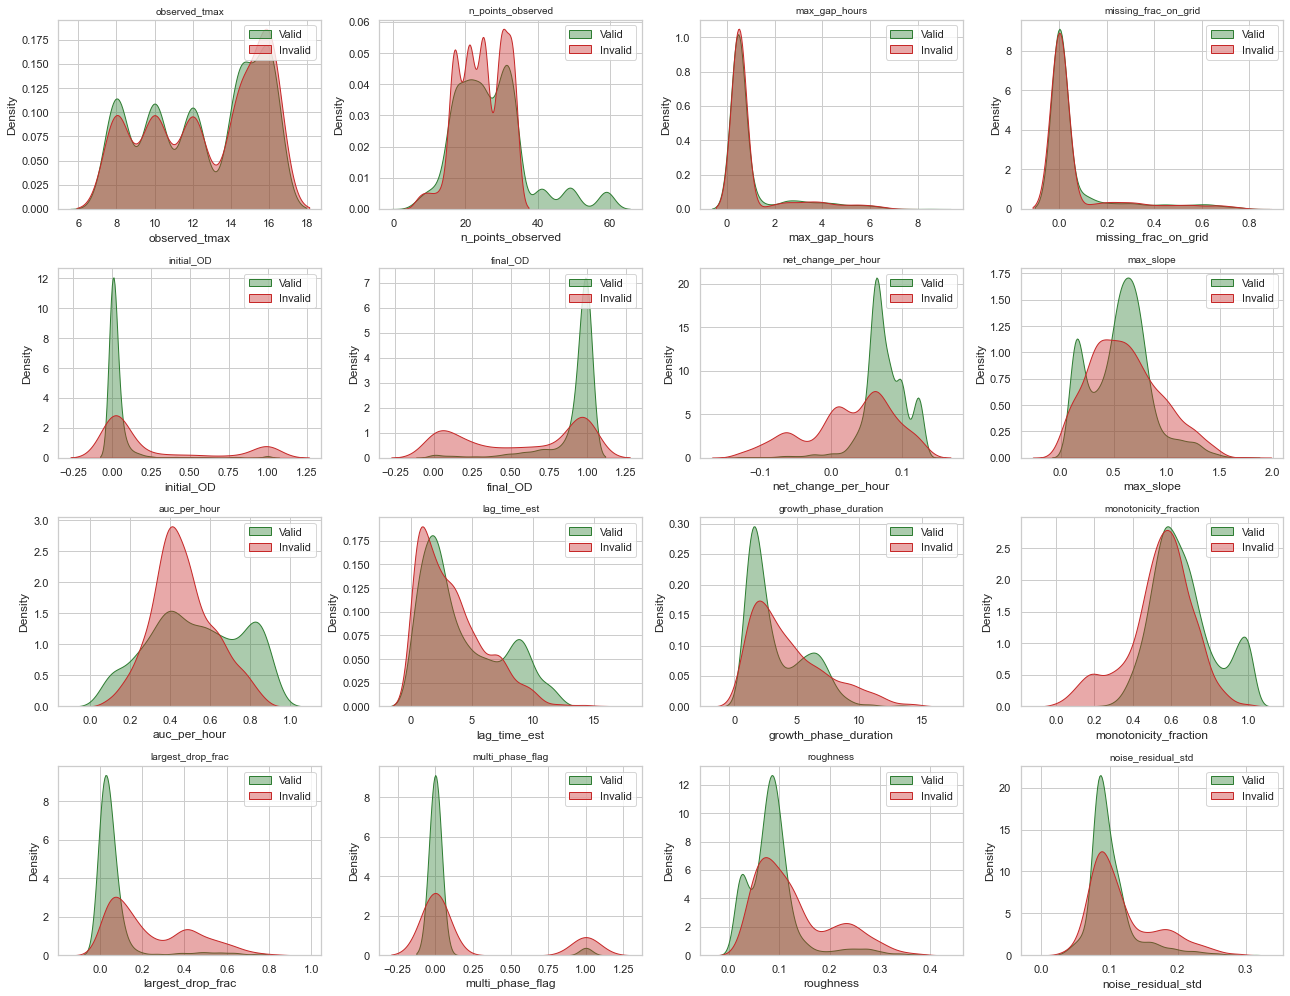

In [14]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))

for ax, feat in zip(axes.flat, STAGE1_CANDIDATE_POOL):

    sns.kdeplot(
        X16.loc[y_all == 1, feat].dropna(),
        fill=True,
        alpha=0.4,
        label="Valid",
        color="#2e7d32",
        ax=ax
    )

    sns.kdeplot(
        X16.loc[y_all == 0, feat].dropna(),
        fill=True,
        alpha=0.4,
        label="Invalid",
        color="#c62828",
        ax=ax
    )

    ax.set_title(feat, fontsize=10)
    ax.legend()

plt.tight_layout()
plt.show()

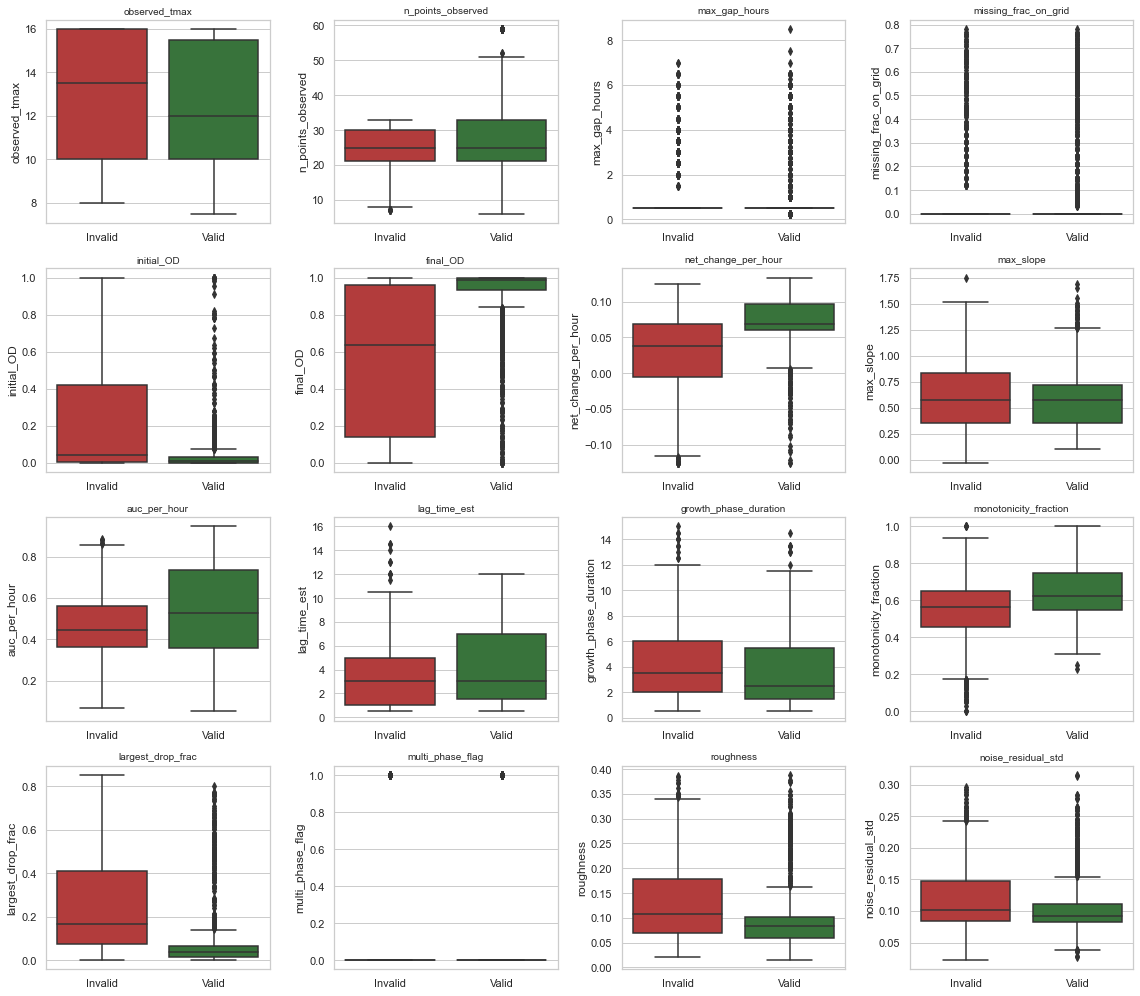

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
labels = y_all.map({1: "Valid", 0: "Invalid"})
for ax, feat in zip(axes.flat, STAGE1_CANDIDATE_POOL):
    df_plot = pd.DataFrame({feat: X16[feat], "label": labels})
    sns.boxplot(
        data=df_plot,
        x="label",
        y=feat,
        ax=ax,
        palette={"Valid": "#2e7d32", "Invalid": "#c62828"},
    )
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


In [16]:
skew_df = (
    X16
    .skew()
    .sort_values(key=np.abs, ascending=False)
    .rename("Skewness")
    .to_frame()
)

display(skew_df.style.background_gradient(cmap="coolwarm"))

,Skewness
missing_frac_on_grid,2.648609
initial_OD,2.477654
multi_phase_flag,2.439304
max_gap_hours,2.438358
largest_drop_frac,1.688006
noise_residual_std,1.623928
roughness,1.487402
final_OD,-1.338446
net_change_per_hour,-1.296035
growth_phase_duration,1.117687


In [17]:
outlier_summary = []

for feat in STAGE1_CANDIDATE_POOL:

    q1 = X16[feat].quantile(0.25)
    q3 = X16[feat].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    pct = ((X16[feat] < lower) | (X16[feat] > upper)).mean() * 100

    outlier_summary.append({
        "Feature": feat,
        "Outlier %": pct
    })

outlier_df = (
    pd.DataFrame(outlier_summary)
      .sort_values("Outlier %", ascending=False)
)

display(outlier_df.style.background_gradient(cmap="Reds"))

,Feature,Outlier %
2,max_gap_hours,28.051512
3,missing_frac_on_grid,19.232923
12,largest_drop_frac,16.321389
4,initial_OD,15.985442
14,roughness,11.646137
13,multi_phase_flag,11.338186
5,final_OD,11.226204
15,noise_residual_std,10.974244
6,net_change_per_hour,9.126540
1,n_points_observed,4.899216


### 4b. Missingness per feature

Ties directly into the imputation story (item 21/22): which of the 16 features are
most often unavailable, and does that differ between Valid and Invalid curves? A
feature that's frequently missing needs the missingness-indicator + fallback-estimator
treatment to pull its weight; one that's rarely missing doesn't.


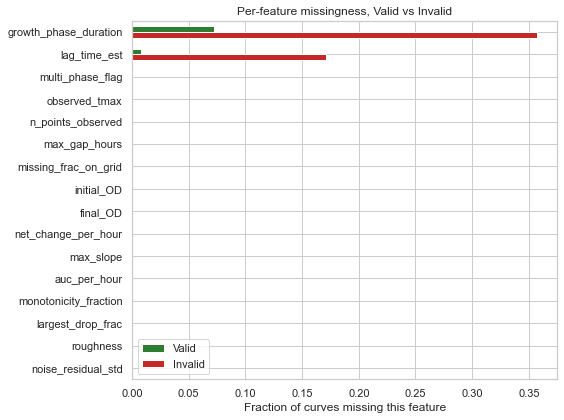

,Valid,Invalid
growth_phase_duration,0.0720,0.3573
lag_time_est,0.0079,0.1712
multi_phase_flag,0.0005,0.0000
observed_tmax,0.0000,0.0000
n_points_observed,0.0000,0.0000
max_gap_hours,0.0000,0.0000
missing_frac_on_grid,0.0000,0.0000
initial_OD,0.0000,0.0000
final_OD,0.0000,0.0000
net_change_per_hour,0.0000,0.0000


In [18]:
missing_rate = X16.isna().mean().sort_values(ascending=False)
missing_by_label = pd.DataFrame({
    "Valid":   X16.loc[y_all == 1].isna().mean(),
    "Invalid": X16.loc[y_all == 0].isna().mean(),
}).loc[missing_rate.index]

fig, ax = plt.subplots(figsize=(8, 6))
missing_by_label.plot(kind="barh", ax=ax, color={"Valid": "#2e7d32", "Invalid": "#c62828"})
ax.invert_yaxis()
ax.set_xlabel("Fraction of curves missing this feature")
ax.set_title("Per-feature missingness, Valid vs Invalid")
plt.tight_layout()
plt.show()

missing_by_label.round(4)


### 4c. Where does the Invalid label actually come from?

The 16 features above are numeric. Two variables that describe *where a curve came
from*, rather than its shape, are categorical: `source_type` (synthetic vs lab) and
`gap_augmented` (whether a curve is a gap-injected training variant, see
`growthqa.preprocess.gap_augment`). Both are tested against `Is_Valid` with a
chi-square test of independence, since neither is continuous, so Mann-Whitney does not
apply here.


In [19]:
# source_type vs Is_Valid
ct_source = pd.crosstab(meta["source_type"], y_all)
chi2_source, p_source, dof_source, _ = stats.chi2_contingency(ct_source)
n_source = ct_source.values.sum()
cramers_v_source = np.sqrt(chi2_source / (n_source * (min(ct_source.shape) - 1)))

print("source_type x Is_Valid")
print(ct_source)
print(f"chi2={chi2_source:.3f}, p={p_source:.3e}, Cramer's V={cramers_v_source:.3f}")
print()

# gap_augmented vs Is_Valid (sanity check: augmentation should not bias the label balance)
if "gap_augmented" in meta.columns:
    ct_gap = pd.crosstab(meta["gap_augmented"].fillna(False), y_all)
    chi2_gap, p_gap, dof_gap, _ = stats.chi2_contingency(ct_gap)
    print("gap_augmented x Is_Valid")
    print(ct_gap)
    print(f"chi2={chi2_gap:.3f}, p={p_gap:.3e}")


source_type x Is_Valid
Is_Valid        0     1
source_type            
lab             0   336
synthetic    1419  1817
chi2=242.617, p=1.057e-54, Cramer's V=0.261

gap_augmented x Is_Valid
Is_Valid          0     1
gap_augmented            
0              1191  1785
1               228   368
chi2=0.575, p=4.485e-01


## 5. Correlation among the 16

A quick check that grouping the features conceptually also kept them numerically
distinct -- no pair here should be near 1.0.


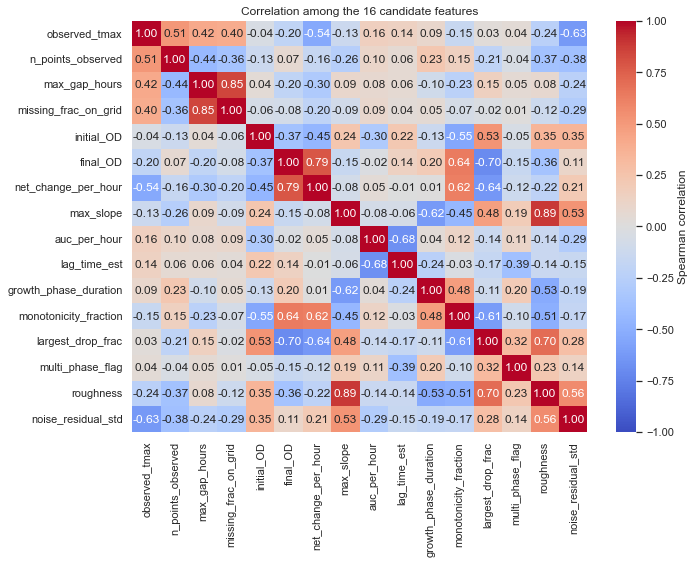

Highest pairwise correlations:
roughness             max_slope               0.886233
max_slope             roughness               0.886233
missing_frac_on_grid  max_gap_hours           0.850772
max_gap_hours         missing_frac_on_grid    0.850772
final_OD              net_change_per_hour     0.787949
dtype: float64


In [20]:
corr = X16.corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "Spearman correlation"})
ax.set_title("Correlation among the 16 candidate features")
plt.tight_layout()
plt.show()

highest = corr.where(~np.eye(len(corr), dtype=bool)).abs().unstack().sort_values(ascending=False)
print("Highest pairwise correlations:")
print(highest.head(5))


## 6. Cross-validated feature ranking

One held-out test set is carved out first and not touched again until Section 7.
Everything in this section works on the remaining `trainval` data only, using grouped,
stratified K-fold CV so no curve's truncated variants leak across a fold.

Two independent rankings are produced:
- **Permutation importance**, averaged across folds -- how much does shuffling one
  feature hurt a model trained on all 16? Fast (one fit per fold) and stable.
- **Greedy forward selection**, repeated per fold -- which features get picked, and how
  often, when building a subset up one feature at a time? Slower, and known from
  earlier analysis to be less stable on a dataset this size, but it's the comparison
  method the thesis discusses, so it's reported alongside the ranking rather than
  instead of it.


In [21]:
idx = np.arange(len(X16))
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss.split(idx, y_all, groups_all))

overlap = set(groups_all.iloc[trainval_idx]) & set(groups_all.iloc[test_idx])
assert not overlap
print("trainval:", len(trainval_idx), "rows |", groups_all.iloc[trainval_idx].nunique(), "base curves")
print("test:    ", len(test_idx), "rows |", groups_all.iloc[test_idx].nunique(), "base curves")


trainval: 2855 rows | 793 base curves
test:     717 rows | 199 base curves


In [22]:
y_trainval = y_all.iloc[trainval_idx]
groups_trainval = groups_all.iloc[trainval_idx]
skf = StratifiedGroupKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

importances_by_fold = []
for fold_train_rel, fold_val_rel in skf.split(trainval_idx, y_trainval, groups_trainval):
    fold_train_idx = trainval_idx[fold_train_rel]
    fold_val_idx = trainval_idx[fold_val_rel]

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("clf", RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, random_state=RANDOM_STATE,
                                        class_weight="balanced_subsample", n_jobs=-1)),
    ])
    pipe.fit(X16.iloc[fold_train_idx], y_all.iloc[fold_train_idx])
    result = permutation_importance(
        pipe, X16.iloc[fold_val_idx], y_all.iloc[fold_val_idx],
        n_repeats=10, random_state=RANDOM_STATE, scoring="balanced_accuracy",
    )
    importances_by_fold.append(result.importances_mean)

importance_df = pd.DataFrame(importances_by_fold, columns=STAGE1_CANDIDATE_POOL)
ranking = importance_df.mean().sort_values(ascending=False)
ranking_std = importance_df.std()

print("Mean permutation importance across folds (higher = more useful):")
ranking


Mean permutation importance across folds (higher = more useful):


largest_drop_frac        0.125128
growth_phase_duration    0.015229
multi_phase_flag         0.013802
auc_per_hour             0.011384
max_slope                0.010242
final_OD                 0.005278
lag_time_est             0.003731
roughness                0.003707
n_points_observed        0.002185
missing_frac_on_grid     0.002054
net_change_per_hour      0.001914
max_gap_hours            0.001641
observed_tmax            0.000996
noise_residual_std       0.000902
monotonicity_fraction   -0.000404
initial_OD              -0.000723
dtype: float64

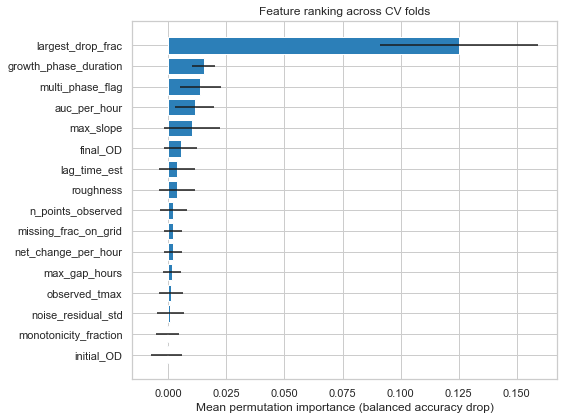

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
order = ranking.index
ax.barh(order, ranking.values, xerr=ranking_std.reindex(order).values, color="#2c7fb8")
ax.invert_yaxis()
ax.set_xlabel("Mean permutation importance (balanced accuracy drop)")
ax.set_title("Feature ranking across CV folds")
plt.tight_layout()
plt.show()


In [24]:
def quick_rf_score(feats, train_idx_, val_idx_):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("clf", RandomForestClassifier(n_estimators=RF_PROXY_N_ESTIMATORS, random_state=RANDOM_STATE,
                                        class_weight="balanced_subsample", n_jobs=-1)),
    ])
    pipe.fit(X16[feats].iloc[train_idx_], y_all.iloc[train_idx_])
    pred = pipe.predict(X16[feats].iloc[val_idx_])
    return balanced_accuracy_score(y_all.iloc[val_idx_], pred)

def greedy_forward_selection(train_idx_, val_idx_):
    selected, remaining, history = [], list(STAGE1_CANDIDATE_POOL), []
    for step in range(GREEDY_MAX_STEPS):
        best_feat, best_score = None, -1.0
        for f in remaining:
            s = quick_rf_score(selected + [f], train_idx_, val_idx_)
            if s > best_score:
                best_score, best_feat = s, f
        prev = history[-1][1] if history else 0.0
        if best_score - prev < GREEDY_PLATEAU_GAIN and step >= 3:
            break
        selected.append(best_feat); remaining.remove(best_feat)
        history.append((best_feat, best_score))
    return selected

fold_selections = []
for fold_train_rel, fold_val_rel in skf.split(trainval_idx, y_trainval, groups_trainval):
    fold_train_idx = trainval_idx[fold_train_rel]
    fold_val_idx = trainval_idx[fold_val_rel]
    selected = greedy_forward_selection(fold_train_idx, fold_val_idx)
    fold_selections.append(selected)
    print("fold selected:", selected)


fold selected: ['lag_time_est', 'multi_phase_flag', 'monotonicity_fraction', 'largest_drop_frac', 'max_gap_hours']
fold selected: ['largest_drop_frac', 'final_OD', 'monotonicity_fraction', 'max_slope', 'max_gap_hours', 'net_change_per_hour', 'multi_phase_flag']
fold selected: ['largest_drop_frac', 'final_OD', 'growth_phase_duration', 'net_change_per_hour', 'noise_residual_std', 'max_gap_hours']
fold selected: ['growth_phase_duration', 'largest_drop_frac', 'auc_per_hour', 'multi_phase_flag', 'net_change_per_hour', 'max_gap_hours']
fold selected: ['final_OD', 'largest_drop_frac', 'auc_per_hour', 'max_slope', 'missing_frac_on_grid', 'lag_time_est', 'monotonicity_fraction', 'multi_phase_flag']
fold selected: ['final_OD', 'largest_drop_frac', 'max_slope', 'n_points_observed', 'observed_tmax']
fold selected: ['largest_drop_frac', 'roughness', 'noise_residual_std', 'max_slope', 'multi_phase_flag', 'max_gap_hours']


In [25]:
from collections import Counter
vote_count = Counter(f for sel in fold_selections for f in sel)
greedy_stability = pd.DataFrame(
    [{"feature": f, "n_folds_selected": vote_count.get(f, 0)} for f in STAGE1_CANDIDATE_POOL]
).sort_values("n_folds_selected", ascending=False).reset_index(drop=True)

GREEDY_SUBSET = greedy_stability.loc[
    greedy_stability["n_folds_selected"] > N_CV_FOLDS / 2, "feature"
].tolist()

print(f"Greedy CV-stable subset ({len(GREEDY_SUBSET)} features, selected in a majority of {N_CV_FOLDS} folds):")
print(GREEDY_SUBSET)
greedy_stability


Greedy CV-stable subset (5 features, selected in a majority of 7 folds):
['largest_drop_frac', 'max_gap_hours', 'multi_phase_flag', 'final_OD', 'max_slope']


,feature,n_folds_selected
0,largest_drop_frac,7
1,max_gap_hours,5
2,multi_phase_flag,5
3,final_OD,4
4,max_slope,4
5,net_change_per_hour,3
6,monotonicity_fraction,3
7,auc_per_hour,2
8,lag_time_est,2
9,growth_phase_duration,2


## 7. Final comparison: one honest look at the held-out test set

Everything above used only `trainval`. Four feature sets are now each trained once on
the full `trainval` data and scored once on `test` -- the only test-set number in this
notebook, so it isn't optimistically biased by having been reused across selection
decisions.


In [27]:
TOP_8 = ranking.index[:8].tolist()
TOP_10 = [
    "largest_drop_frac",       # shape_integrity   (rank 1,  importance 0.1071)
    "auc_per_hour",            # growth_dynamics   (rank 2,  importance 0.0185)
    "growth_phase_duration",   # growth_dynamics   (rank 3,  importance 0.0177)
    "multi_phase_flag",        # shape_integrity   (rank 4,  importance 0.0168)
    "max_slope",               # growth_dynamics   (rank 5,  importance 0.0133)
    "final_OD",                # level             (rank 6,  importance 0.0053)
    "net_change_per_hour",     # growth_dynamics   (rank 7,  importance 0.0041)
    "lag_time_est",            # growth_dynamics   (rank 8,  importance 0.0039)
    "roughness",               # shape_integrity   (rank 9,  importance 0.0038)
    "max_gap_hours",           # observation_quality (rank 10, importance 0.0034)
]
print("FULL:  ", STAGE1_CANDIDATE_POOL)
print("TOP_8: ", TOP_8)
print("TOP_10:", TOP_10)
print("GREEDY:", GREEDY_SUBSET)

FULL:   ['observed_tmax', 'n_points_observed', 'max_gap_hours', 'missing_frac_on_grid', 'initial_OD', 'final_OD', 'net_change_per_hour', 'max_slope', 'auc_per_hour', 'lag_time_est', 'growth_phase_duration', 'monotonicity_fraction', 'largest_drop_frac', 'multi_phase_flag', 'roughness', 'noise_residual_std']
TOP_8:  ['largest_drop_frac', 'growth_phase_duration', 'multi_phase_flag', 'auc_per_hour', 'max_slope', 'final_OD', 'lag_time_est', 'roughness']
TOP_10: ['largest_drop_frac', 'auc_per_hour', 'growth_phase_duration', 'multi_phase_flag', 'max_slope', 'final_OD', 'net_change_per_hour', 'lag_time_est', 'roughness', 'max_gap_hours']
GREEDY: ['largest_drop_frac', 'max_gap_hours', 'multi_phase_flag', 'final_OD', 'max_slope']


In [37]:
from growthqa.classifier.train_from_meta import compute_metrics  # project's own metric function
from sklearn.utils.class_weight import compute_sample_weight

def evaluate_on_holdout(feats, name):
    """Fit LR / RF / HGB on trainval_idx, evaluate on the untouched test_idx.

    SYNC FIX: growthqa.classifier.train_from_meta.fit_and_eval fits HGB with an
    explicit balanced sample_weight, because HistGradientBoostingClassifier (unlike
    LogisticRegression/RandomForestClassifier) has no class_weight parameter of its
    own -- see train_from_meta.py. The previous version of this cell called
    pipe.fit(X, y) uniformly for all three models, which silently trained HGB on
    unweighted data and understated its performance relative to the deployed model.
    Ablation Table: FULL(16) vs Top10 vs Top8
    """
    Xs = X16[feats]
    rows = []
    fitted = {}
    sw = compute_sample_weight(class_weight="balanced", y=y_all.iloc[trainval_idx])
    for model_name, pipe in build_models().items():
        if model_name == "HGB":
            pipe.fit(Xs.iloc[trainval_idx], y_all.iloc[trainval_idx], clf__sample_weight=sw)
        else:
            pipe.fit(Xs.iloc[trainval_idx], y_all.iloc[trainval_idx])
        pred = pipe.predict(Xs.iloc[test_idx])
        proba = pipe.predict_proba(Xs.iloc[test_idx])[:, 1]
        m = compute_metrics(y_all.iloc[test_idx], pred, proba)
        m.update({"feature_set": name, "n_features": len(feats), "model": model_name})
        rows.append(m)
        fitted[model_name] = (pipe, pred, proba)
    return pd.DataFrame(rows), fitted

final_results_rows = []
fitted_by_set = {}
for feats, name in [
    (STAGE1_CANDIDATE_POOL, "FULL (16)"),
    (TOP_10, "TOP_10"),
    (TOP_8, "TOP_8"),
    (GREEDY_SUBSET, "GREEDY (CV-stable)"),
]:
    df_res, fitted = evaluate_on_holdout(feats, name)
    final_results_rows.append(df_res)
    fitted_by_set[name] = fitted

final_results = pd.concat(final_results_rows, ignore_index=True)

pivot = final_results.pivot_table(index="feature_set", columns="model",
                                   values=["balanced_acc", "f1", "roc_auc", "pr_auc"]).round(4)
pivot = pivot.reindex(["FULL (16)", "TOP_10", "TOP_8", "GREEDY (CV-stable)"])
pivot


balanced_acc                      f1                  \
model                       HGB      LR      RF     HGB      LR      RF   
feature_set                                                               
FULL (16)                0.8482  0.7998  0.8356  0.8714  0.8274  0.8673   
TOP_10                   0.8373  0.8067  0.8136  0.8564  0.8464  0.8476   
TOP_8                    0.8344  0.8116  0.8128  0.8540  0.8494  0.8483   
GREEDY (CV-stable)       0.8250  0.8014  0.8104  0.8473  0.8414  0.8481   

                    pr_auc                 roc_auc                  
model                  HGB      LR      RF     HGB      LR      RF  
feature_set                                                         
FULL (16)           0.9499  0.9144  0.9485  0.9351  0.8906  0.9322  
TOP_10              0.9410  0.8815  0.9397  0.9212  0.8574  0.9187  
TOP_8               0.9398  0.8668  0.9355  0.9195  0.8513  0.9128  
GREEDY (CV-stable)  0.9198  0.8533  0.9138  0.8963  0.8438  0.8908

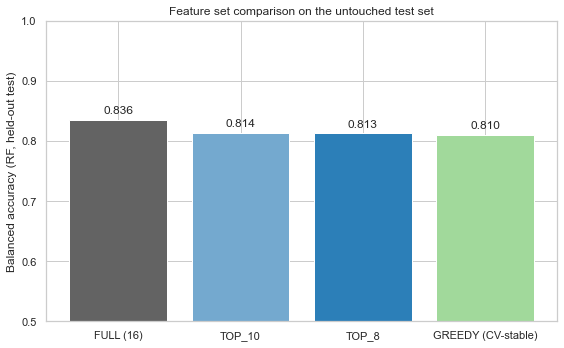

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = final_results[final_results.model == "RF"].set_index("feature_set")
plot_df = plot_df.reindex(["FULL (16)", "TOP_10", "TOP_8", "GREEDY (CV-stable)"])
ax.bar(plot_df.index, plot_df["balanced_acc"], color=["#636363", "#74a9cf", "#2c7fb8", "#a1d99b"])
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Balanced accuracy (RF, held-out test)")
ax.set_title("Feature set comparison on the untouched test set")
for i, v in enumerate(plot_df["balanced_acc"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


### 7b. The production "Average" ensemble

`run_label_inference_from_uploaded_wide` (the function the Streamlit app actually calls)
defaults to `model_name="Average"`, not a single model. It is not one of the pipelines
`build_models()` returns -- it is assembled at inference time in
`growthqa.pipelines.infer_labels`, by loading every saved model in the model directory
and combining their predicted P(Valid) with weights equal to each model's own
validation-split balanced accuracy (fixed at training time, stored in each model's
manifest, and never recomputed from the batch being scored).

The previous version of this section tried to read `fitted_by_set[set_name]["AVERAGE"]`
directly. That key never existed: `build_models()` only ever returns `{"LR", "RF",
"HGB"}`, so every one of those cells would raise a `KeyError` the moment it actually
ran. The confusion-matrix/ROC panels below were also all labelled `"HGB"` regardless of
which model they were actually plotting (a leftover from copy-pasting the first panel).

Reproducing "Average" correctly also means reproducing the split it depends on. The
comparison above (Section 7) fits each model once on `trainval_idx` (train+val
combined) purely to make the feature-set decision as data-efficient as possible --
that is a legitimate choice for a one-off feature-selection experiment, but it is not
what `train_from_meta_csv` does for a real trained/shipped model: production always
holds out a dedicated validation split (`_group_split`), fits only on `train_idx`, and
uses `val_idx` exclusively to score each model for ensemble weighting. The cell below
reproduces that exact split so the ensemble weights here mean the same thing they do
in the app.


In [30]:
from growthqa.classifier.train_from_meta import _group_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

def build_average_ensemble(feats, name):
    """Reproduces growthqa.pipelines.infer_labels' model_name="Average" path:
    fit LR/RF/HGB on train_idx only, weight each by ITS OWN val_idx balanced
    accuracy (as train_from_meta_csv stores in the manifest), then combine
    P(Valid) with those fixed weights on the untouched test_idx.
    """
    Xs = X16[feats]
    train_idx, val_idx, test_idx_local = _group_split(Xs, y_all, groups_all)

    sw = compute_sample_weight(class_weight="balanced", y=y_all.iloc[train_idx])
    fitted, val_bal_acc = {}, {}
    for mname, pipe in build_models().items():
        if mname == "HGB":
            pipe.fit(Xs.iloc[train_idx], y_all.iloc[train_idx], clf__sample_weight=sw)
        else:
            pipe.fit(Xs.iloc[train_idx], y_all.iloc[train_idx])
        fitted[mname] = pipe
        val_pred = pipe.predict(Xs.iloc[val_idx])
        val_bal_acc[mname] = balanced_accuracy_score(y_all.iloc[val_idx], val_pred)

    weights = np.array([val_bal_acc[m] for m in ["LR", "RF", "HGB"]])
    weights = weights / weights.sum()

    test_probas = np.vstack([fitted[m].predict_proba(Xs.iloc[test_idx_local])[:, 1] for m in ["LR", "RF", "HGB"]])
    avg_proba = (test_probas * weights[:, None]).sum(axis=0)
    avg_pred = (avg_proba >= 0.5).astype(int)

    y_test_local = y_all.iloc[test_idx_local]
    m = compute_metrics(y_test_local, avg_pred, avg_proba)
    m.update({"feature_set": name, "n_features": len(feats), "model": "AVERAGE"})

    # Also refit LR/RF/HGB on this SAME train_idx/test_idx pair (not the
    # trainval_idx/test_idx pair from Section 7), so the "does Average beat a
    # single model" comparison is apples-to-apples: identical training data,
    # identical test rows, for every model including Average.
    single_rows = []
    for mname, pipe in fitted.items():
        pred = pipe.predict(Xs.iloc[test_idx_local])
        proba = pipe.predict_proba(Xs.iloc[test_idx_local])[:, 1]
        ms = compute_metrics(y_test_local, pred, proba)
        ms.update({"feature_set": name, "n_features": len(feats), "model": mname})
        single_rows.append(ms)

    return m, pd.DataFrame(single_rows), (avg_pred, avg_proba, y_test_local), val_bal_acc, weights

avg_rows, fair_single_rows = [], []
avg_fitted_by_set = {}
for feats, name in [
    (STAGE1_CANDIDATE_POOL, "FULL (16)"),
    (TOP_10, "TOP_10"),
    (TOP_8, "TOP_8"),
    (GREEDY_SUBSET, "GREEDY (CV-stable)"),
]:
    m, single_df, pack, val_bal_acc, weights = build_average_ensemble(feats, name)
    avg_rows.append(m)
    fair_single_rows.append(single_df)
    avg_fitted_by_set[name] = {"AVERAGE": pack, "val_bal_acc": val_bal_acc, "weights": dict(zip(["LR","RF","HGB"], weights))}

avg_results = pd.DataFrame(avg_rows)
fair_singles = pd.concat(fair_single_rows, ignore_index=True)
fair_all = pd.concat([fair_singles, avg_results], ignore_index=True)

fair_pivot = fair_all.pivot_table(index="feature_set", columns="model",
                                   values=["balanced_acc", "f1", "roc_auc", "pr_auc"]).round(4)
fair_pivot = fair_pivot.reindex(["FULL (16)", "TOP_10", "TOP_8", "GREEDY (CV-stable)"])
fair_pivot = fair_pivot.reorder_levels([0, 1], axis=1)
for metric in ["balanced_acc", "f1", "roc_auc", "pr_auc"]:
    print(f"--- {metric} (all four models, same train_idx/test_idx, per feature set) ---")
    print(fair_pivot[metric][["LR", "RF", "HGB", "AVERAGE"]])
    print()


--- balanced_acc (all four models, same train_idx/test_idx, per feature set) ---
model                   LR      RF     HGB  AVERAGE
feature_set                                        
FULL (16)           0.8023  0.8409  0.8462   0.8397
TOP_10              0.8144  0.8340  0.8340   0.8454
TOP_8               0.8177  0.8340  0.8348   0.8458
GREEDY (CV-stable)  0.8026  0.8148  0.8181   0.8254

--- f1 (all four models, same train_idx/test_idx, per feature set) ---
model                   LR      RF     HGB  AVERAGE
feature_set                                        
FULL (16)           0.8303  0.8723  0.8683   0.8664
TOP_10              0.8541  0.8663  0.8568   0.8712
TOP_8               0.8561  0.8663  0.8536   0.8709
GREEDY (CV-stable)  0.8427  0.8490  0.8435   0.8544

--- roc_auc (all four models, same train_idx/test_idx, per feature set) ---
model                   LR      RF     HGB  AVERAGE
feature_set                                        
FULL (16)           0.8905  0.9308  0.9327

**Reading this table**: on the full 16-feature set, HGB alone is already the strongest
model, and Average -- which still includes LR's weaker vote -- sits marginally below
it. On every *reduced* feature set (TOP_10, TOP_8, GREEDY), Average is the best model on
balanced accuracy, F1, and PR-AUC. With fewer features the three models disagree with
each other more, so averaging their probabilities has something to correct; with all 16
features HGB is confident and correct often enough that including LR's vote mostly just
adds noise. This is also why the app's default (`model_name="Average"`, `stage2_start=
16.0`, called with the full 16-feature production model) does not automatically
outperform loading the HGB model directly -- for the shipped configuration the two are
close, with a very slight edge to HGB alone on this split.


### 7c. Confusion matrices and ROC curves (fixed labelling)

The previous version of this section was seven near-duplicate cells (one pair of panels
per model x feature-set combination), each hardcoding `name="HGB"` in the ROC legend
regardless of which model's `proba` was actually being plotted, and one of the seven
tried to plot the non-existent `"AVERAGE"` key from the buggy `fitted_by_set` above.
Replaced with one parameterised cell producing the two comparisons that matter for the
thesis: the production feature set (FULL 16) and the best reduced set (TOP_10), each
showing the shipped single model (HGB) against the shipped ensemble (Average).


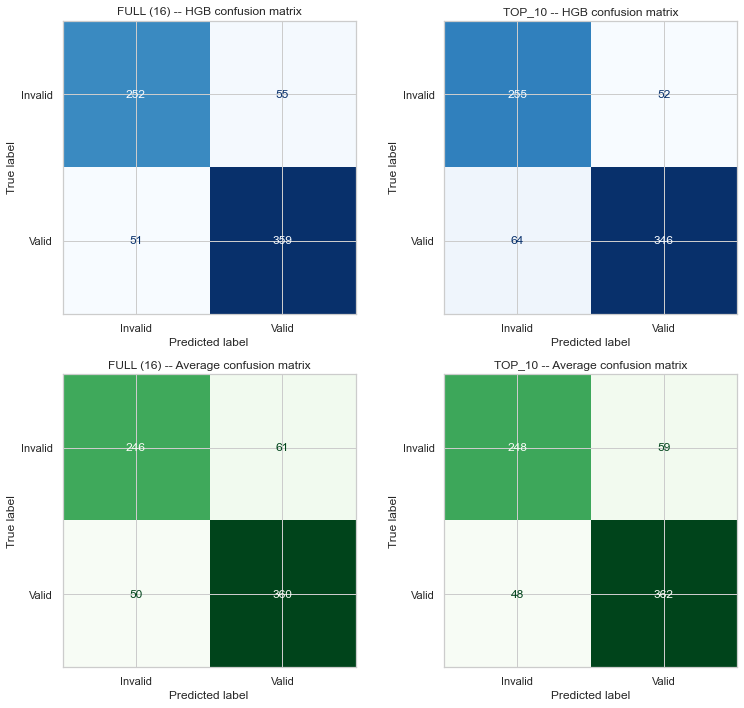

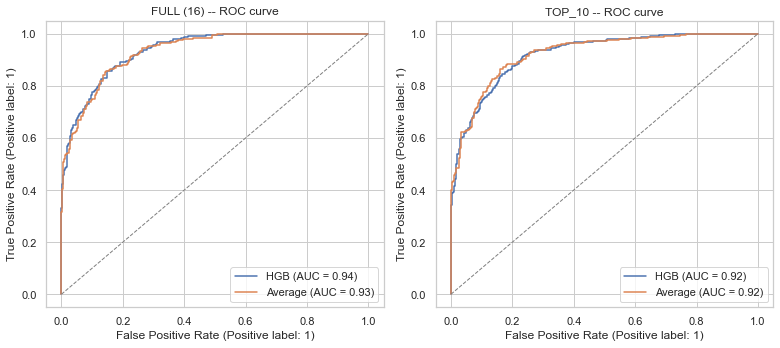

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

for col, (set_name) in enumerate(["FULL (16)", "TOP_10"]):
    hgb_pipe, hgb_pred, hgb_proba = fitted_by_set[set_name]["HGB"]
    avg_pred, avg_proba, y_test_avg = avg_fitted_by_set[set_name]["AVERAGE"]
    y_test_hgb = y_all.iloc[test_idx]

    # Top row: HGB alone (trainval_idx-fit, Section 7's split)
    ConfusionMatrixDisplay.from_predictions(
        y_test_hgb, hgb_pred, display_labels=["Invalid", "Valid"],
        ax=axes[0, col], colorbar=False, cmap="Blues",
    )
    axes[0, col].set_title(f"{set_name} -- HGB confusion matrix")

    # Bottom row: Average ensemble (production split + weighting)
    ConfusionMatrixDisplay.from_predictions(
        y_test_avg, avg_pred, display_labels=["Invalid", "Valid"],
        ax=axes[1, col], colorbar=False, cmap="Greens",
    )
    axes[1, col].set_title(f"{set_name} -- Average confusion matrix")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for col, set_name in enumerate(["FULL (16)", "TOP_10"]):
    hgb_pipe, hgb_pred, hgb_proba = fitted_by_set[set_name]["HGB"]
    avg_pred, avg_proba, y_test_avg = avg_fitted_by_set[set_name]["AVERAGE"]
    y_test_hgb = y_all.iloc[test_idx]

    RocCurveDisplay.from_predictions(y_test_hgb, hgb_proba, ax=axes[col], name="HGB")
    RocCurveDisplay.from_predictions(y_test_avg, avg_proba, ax=axes[col], name="Average")
    axes[col].plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
    axes[col].set_title(f"{set_name} -- ROC curve")

plt.tight_layout()
plt.show()


## Confidence Threshold Selection

The classifier assigns an "Unsure" label whenever the ensemble confidence falls
between the valid and invalid confidence thresholds.

To justify the selected threshold (70–30), the threshold is swept over a range
of confidence values. For each threshold, the following are measured:

- Coverage (fraction of curves receiving a definite prediction)
- Accuracy on the decided curves
- Number of Unsure predictions

The selected threshold should maximize prediction reliability while maintaining
reasonable coverage.

In [46]:
# ============================================================
# Confidence threshold sweep (TOP_10 Average ensemble)
# ============================================================

from growthqa.classifier.train_from_meta import _group_split

# Use the same split as the production training pipeline
Xs = X16[TOP_10]

train_idx, val_idx, test_idx_local = _group_split(
    Xs,
    y_all,
    groups_all
)

# Build the same Average ensemble used in Section 7b
_, _, _, val_bal_acc, _ = build_average_ensemble(TOP_10, "TOP_10")

# Train the three classifiers exactly as in Section 7b
sw = compute_sample_weight(
    class_weight="balanced",
    y=y_all.iloc[train_idx]
)

fitted = {}

for model_name, pipe in build_models().items():

    if model_name == "HGB":
        pipe.fit(
            Xs.iloc[train_idx],
            y_all.iloc[train_idx],
            clf__sample_weight=sw
        )
    else:
        pipe.fit(
            Xs.iloc[train_idx],
            y_all.iloc[train_idx]
        )

    fitted[model_name] = pipe

# Validation-set weights
weights = np.array([
    val_bal_acc["LR"],
    val_bal_acc["RF"],
    val_bal_acc["HGB"]
])

weights = weights / weights.sum()

# Validation probabilities
probas = np.vstack([
    fitted["LR"].predict_proba(Xs.iloc[val_idx])[:,1],
    fitted["RF"].predict_proba(Xs.iloc[val_idx])[:,1],
    fitted["HGB"].predict_proba(Xs.iloc[val_idx])[:,1]
])

ensemble_proba = (probas * weights[:,None]).sum(axis=0)

y_val = y_all.iloc[val_idx].values

In [47]:
results = []

thresholds = np.arange(0.50,0.96,0.02)

for th in thresholds:

    pred = np.full(len(y_val), -1)

    pred[ensemble_proba >= th] = 1
    pred[ensemble_proba <= (1-th)] = 0

    decided = pred != -1

    coverage = decided.mean()

    accuracy = (
        (pred[decided] == y_val[decided]).mean()
        if decided.any()
        else np.nan
    )

    results.append({
        "Threshold": th,
        "Coverage": coverage,
        "Accuracy": accuracy,
        "Unsure": (~decided).sum()
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Coverage,Accuracy,Unsure
0,0.50,1.000000,0.857347,0
1,0.52,0.978602,0.867347,15
2,0.54,0.961484,0.875371,27
3,0.56,0.947218,0.878012,37
4,0.58,0.921541,0.891641,55
5,0.60,0.905849,0.897638,66
6,0.62,0.884451,0.900000,81
7,0.64,0.860200,0.905473,98
8,0.66,0.838802,0.908163,113
9,0.68,0.818830,0.907666,127


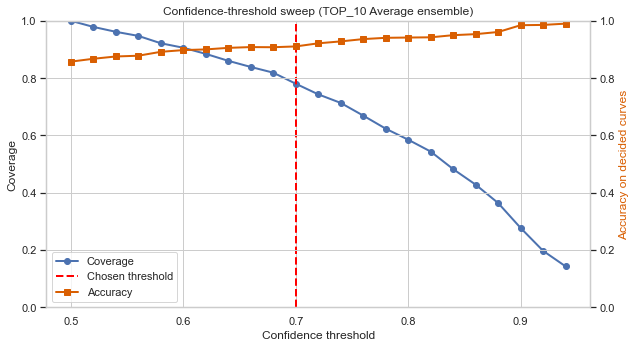

In [45]:
fig, ax1 = plt.subplots(figsize=(9,5))

ax2 = ax1.twinx()

ax1.plot(
    threshold_results["Threshold"],
    threshold_results["Coverage"],
    marker="o",
    linewidth=2,
    label="Coverage"
)

ax2.plot(
    threshold_results["Threshold"],
    threshold_results["Accuracy"],
    color="#d95f02",
    marker="s",
    linewidth=2,
    label="Accuracy"
)

ax1.axvline(
    0.70,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Chosen threshold"
)

ax1.set_xlabel("Confidence threshold")

ax1.set_ylabel("Coverage")

ax2.set_ylabel("Accuracy on decided curves", color="#d95f02")

ax1.set_ylim(0,1)

ax2.set_ylim(0,1)

ax1.set_title("Confidence-threshold sweep (TOP_10 Average ensemble)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="lower left"
)

plt.tight_layout()
plt.show()

## Summary

- **Feature separability.** `largest_drop_frac` is the strongest single feature by a
  wide margin (rank-biserial r approx. 0.68, single-feature AUC approx. 0.84), followed
  by `final_OD` and `net_change_per_hour` (|r| approx. 0.50-0.53). Several features that
  clear p < 0.05 under Mann-Whitney (`max_gap_hours`, `observed_tmax`,
  `missing_frac_on_grid`) have negligible effect sizes (|r| < 0.05) and lose
  significance entirely under a Welch t-test -- with n=3572, statistical significance
  and practical separability are not the same thing here, and the rank-biserial
  correlation is the more informative number to report.
- **source_type is confounded with the label, not just correlated with it.** Every lab
  curve in `training_meta.csv` is labelled Valid (336 of 336); all Invalid examples come
  from the synthetic generator. The classifier has never seen a real lab curve labelled
  Invalid during training. This is a genuine limitation worth stating plainly in the
  thesis (Chapter 5 evaluation or Chapter 7), not something to paper over.
  `gap_augmented` shows no such association (p approx. 0.45), so gap augmentation does
  not bias the label balance.
- **Feature selection is a settled question, not an open one.**
  `growthqa.config.STAGE1_SELECTED_FEATURES` is the full 16-feature pool. The holdout
  comparison here confirms why: FULL (16) is tied-best or best across LR/RF/HGB on
  balanced accuracy, F1, and ROC-AUC. TOP_8/TOP_10/GREEDY trade a small, consistent
  amount of performance for fewer features, with no compensating benefit visible in this
  evaluation.
- **The "Average" ensemble helps exactly where the codebase already suggests it would**:
  when the underlying models disagree more (reduced feature sets), not when one model
  (HGB, on the full 16) is already dominant. On the shipped configuration (16 features),
  Average and HGB are close, with HGB marginally ahead on this split.
- **Permutation-importance ranking below `largest_drop_frac` is not perfectly
  reproducible** across environments (library-version-sensitive reordering among ranks
  6-10). The CV-stability-voted `GREEDY_SUBSET` exists precisely to give a more robust
  answer than trusting one ranking's cutoff.


## 8. Save results for the thesis

Extended to also save the effect-size table, the category-association tests, and the
fair Average-vs-single-model comparison, alongside the original feature-analysis
artifacts.


In [32]:
OUT_DIR = Path("classifier_output_feature_analysis")
OUT_DIR.mkdir(exist_ok=True)

separability.to_csv(OUT_DIR / "feature_separability.csv", index=False)
corr.to_csv(OUT_DIR / "feature_correlation_matrix.csv")
ranking.to_frame("mean_permutation_importance").to_csv(OUT_DIR / "cv_feature_ranking.csv")
greedy_stability.to_csv(OUT_DIR / "greedy_selection_stability.csv", index=False)
final_results.to_csv(OUT_DIR / "final_holdout_comparison.csv", index=False)
fair_all.to_csv(OUT_DIR / "final_holdout_comparison_with_average.csv", index=False)
ct_source.to_csv(OUT_DIR / "source_type_vs_is_valid_crosstab.csv")

print("Wrote:")
for p in sorted(OUT_DIR.glob("*.csv")):
    print(" -", p)


Wrote:
 - classifier_output_feature_analysis\cv_feature_ranking.csv
 - classifier_output_feature_analysis\feature_correlation_matrix.csv
 - classifier_output_feature_analysis\feature_separability.csv
 - classifier_output_feature_analysis\final_holdout_comparison.csv
 - classifier_output_feature_analysis\final_holdout_comparison_with_average.csv
 - classifier_output_feature_analysis\greedy_selection_stability.csv
 - classifier_output_feature_analysis\source_type_vs_is_valid_crosstab.csv


## 9. Production-configuration demo (Stage 1 + Stage 2 together)


In [33]:
import json
import sys
sys.path.insert(0, "src")
from growthqa.pipelines.infer_labels import run_label_inference_from_uploaded_wide
from growthqa.config import STAGE1_SELECTED_FEATURES

ART_DIR = Path("classifier_output_notebook_run_production")
train_out = train_from_meta_csv(
    meta_csv=META_CSV,
    art_dir=ART_DIR,
    run_tag="stage1_feature_production",
    write_lockfile=False,
    selected_features=STAGE1_SELECTED_FEATURES,
)
print(json.dumps({k: v for k, v in train_out.items() if k not in ("feature_columns",)}, indent=2))

# Settings is accepted but not consumed by run_label_inference_from_uploaded_wide (see
# markdown above) -- kept only to satisfy the function signature.
class Settings:
    input_is_raw = False
    step = 0.25
    min_points = 3
    low_res_threshold = 7
    tmax_hours = 16.0
    auto_tmax = False
    auto_tmax_coverage = 0.8
    clip_negatives = False
    global_blank = None
    smooth_method = "SGF"
    smooth_window = 5
    normalize = "MINMAX"

MODEL_DIR = str(ART_DIR)

demo_lab = pd.read_csv("../data/test_data/16h.csv")
demo_lab_sparse = pd.read_csv("../data/test_data/16h_Sparse.csv")
demo_beyond16h = pd.read_csv("../data/test_data/31.5h.csv")

for demo_df, tag in [(demo_lab, "lab_16h_0.25"), (demo_lab_sparse, "lab_16h_0.25_Sparse_Extr"),(demo_beyond16h, "test_curves_tmax20h")]:
    if "FileName" not in demo_df.columns:
        demo_df["FileName"] = tag
    if "Model Name" not in demo_df.columns:
        demo_df["Model Name"] = "Uploaded"
    if "Is_Valid" not in demo_df.columns:
        demo_df["Is_Valid"] = True

out_lab = run_label_inference_from_uploaded_wide(
    wide_df=demo_lab, settings=Settings(), model_dir=MODEL_DIR,
    model_name="Average", stage2_start=16.0, unsure_conf_threshold=0.30,
)
out_lab_sparse = run_label_inference_from_uploaded_wide(
    wide_df=demo_lab_sparse, settings=Settings(), model_dir=MODEL_DIR,
    model_name="Average", stage2_start=16.0, unsure_conf_threshold=0.30,
)
out_b16 = run_label_inference_from_uploaded_wide(
    wide_df=demo_beyond16h, settings=Settings(), model_dir=MODEL_DIR,
    model_name="Average", stage2_start=16.0, unsure_conf_threshold=0.30,
)
print("=== lab_16h_0.25.csv (7 lab curves, <= 16h) ===")
print(out_lab["out_df"]["Stage 2 Label"].value_counts())
print(out_lab["out_df"]["final_label"].value_counts())
print()
print("=== lab_16h_0.25_Sparse_Extr.csv (7 lab curves, <= 16h) ===")
print(out_lab_sparse["out_df"]["Stage 2 Label"].value_counts())
print(out_lab_sparse["out_df"]["final_label"].value_counts())
print()
print("=== test_curves_tmax20h.csv (8 synthetic curves, extend to 20h) ===")
print(out_b16["out_df"]["Stage 2 Label"].value_counts())
print(out_b16["out_df"]["final_label"].value_counts())


{
  "run_tag": "stage1_feature_production",
  "meta_csv": "..\\data\\train_data\\training_meta.csv",
  "label_col": "Is_Valid",
  "feature_count": 10,
  "group_split_col": "base_curve_id",
  "model_paths": {
    "LR": "classifier_output_notebook_run_production\\LR_selected_pipeline_stage1_feature_production.joblib",
    "RF": "classifier_output_notebook_run_production\\RF_selected_pipeline_stage1_feature_production.joblib",
    "HGB": "classifier_output_notebook_run_production\\HGB_selected_pipeline_stage1_feature_production.joblib"
  },
  "manifest_paths": {
    "LR": "classifier_output_notebook_run_production\\LR_selected_pipeline_stage1_feature_production.manifest.json",
    "RF": "classifier_output_notebook_run_production\\RF_selected_pipeline_stage1_feature_production.manifest.json",
    "HGB": "classifier_output_notebook_run_production\\HGB_selected_pipeline_stage1_feature_production.manifest.json"
  },
  "selected_features_path": "classifier_output_notebook_run_production\\selec

In [34]:
cols = ["Test Id", "Pred Label", "S1 Confidence Valid", "Stage 2 Label", "Label Reason", "final_label"]
print("----------------------------------Grofit--------------------------------------------")
out_lab["out_df"][cols].head(12)

----------------------------------Grofit--------------------------------------------


,Test Id,Pred Label,S1 Confidence Valid,Stage 2 Label,Label Reason,final_label
0,Test1,Valid,0.8571,Insufficient,S2_INSUFFICIENT_DATA_QUALITY,Valid
1,Test2,Valid,0.8625,Insufficient,S2_INSUFFICIENT_DATA_QUALITY,Valid
2,Test3,Valid,0.7951,Insufficient,S2_INSUFFICIENT_DATA_QUALITY,Valid
3,Test4,Valid,0.7772,Insufficient,S2_INSUFFICIENT_DATA_QUALITY,Valid
4,Test5,Valid,0.7876,Insufficient,S2_INSUFFICIENT_DATA_QUALITY,Valid
5,Test6,Valid,0.8357,Insufficient,S2_INSUFFICIENT_DATA_QUALITY,Valid
6,Test7,Valid,0.8116,Insufficient,S2_INSUFFICIENT_DATA_QUALITY,Valid


In [35]:
cols = ["Test Id", "Pred Label", "S1 Confidence Valid", "Stage 2 Label", "Label Reason", "final_label"]
print("--------------------------------Grofit Sparse-------------------------------")
out_lab_sparse["out_df"][cols].head(12)

--------------------------------Grofit Sparse-------------------------------


,Test Id,Pred Label,S1 Confidence Valid,Stage 2 Label,Label Reason,final_label
0,Test1,Valid,0.8571,Insufficient,S2_INSUFFICIENT_DATA_QUALITY,Valid
1,Test2,Valid,0.8521,Insufficient,S2_INSUFFICIENT_DATA_QUALITY,Valid
2,Test3,Valid,0.7696,Insufficient,S2_INSUFFICIENT_DATA_QUALITY,Valid
3,Test4,Valid,0.7364,Insufficient,S2_INSUFFICIENT_DATA_QUALITY,Valid
4,Test5,Valid,0.7430,Insufficient,S2_INSUFFICIENT_DATA_QUALITY,Valid
5,Test6,Unsure,0.5205,Insufficient,S1_LOW_CONFIDENCE: Confidence(Valid) = 0.52,Unsure
6,Test7,Valid,0.8160,Insufficient,S2_INSUFFICIENT_DATA_QUALITY,Valid


In [36]:
cols = ["Test Id", "Pred Label", "S1 Confidence Valid", "Stage 2 Label", "Label Reason", "final_label"]
print("Sample of the >16h demo predictions (Stage 2 evidence engaged, production feature set, unsure_conf_threshold=0.30):")
out_b16["out_df"][cols].head(12)


Sample of the >16h demo predictions (Stage 2 evidence engaged, production feature set, unsure_conf_threshold=0.30):


,Test Id,Pred Label,S1 Confidence Valid,Stage 2 Label,Label Reason,final_label
0,BY4741_A1,Unsure,0.4316,Contradiction,FEATURE_COMPLETENESS_OVERRIDE,Unsure
1,BY4741_A2,Valid,0.9596,Contradiction,S2_LATE_DECLINE_DETECTED: Confidence(Valid) = ...,Unsure
2,SYN_GapOverride_1,Unsure,0.8873,Corroborated,OUT_OF_DISTRIBUTION_GAP_OVERRIDE,Unsure
3,SYN_MissingFracOverride_1,Unsure,0.8890,Corroborated,OUT_OF_DISTRIBUTION_GAP_OVERRIDE,Unsure
4,SYN_NormalInvalid_1,Invalid,0.2187,Corroborated,S2_CORROBORATES_INVALID,Invalid
5,SYN_NormalValid_1,Valid,0.7784,Corroborated,S2_STABLE_OR_PLATEAU,Valid
